# VisDrone2019-DET Colab setup

This standalone notebook prepares the benchmark dataset without installing any model
framework. A normal run persists verified archives, unchanged raw data, Track A
(`person`, `vehicle`) COCO, Track B (official classes 1–10) COCO, manifests,
statistics, validation reports, visualizations, and a DataLoader smoke result.

Expected persistent root:
`/content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET`.


## 1. Runtime diagnostics


In [1]:
import os, platform, shutil, sys
print("Python:", sys.version)
print("Platform:", platform.platform())
try:
    import psutil
    print("RAM GiB:", round(psutil.virtual_memory().total / 2**30, 2))
except ImportError:
    print("RAM: install cell has not run yet")
usage = shutil.disk_usage("/content" if os.path.isdir("/content") else ".")
print("Free disk GiB:", round(usage.free / 2**30, 2))
try:
    import torch
    print("PyTorch:", torch.__version__)
    print("torchvision:", __import__("torchvision").__version__)
    print("CUDA build:", torch.version.cuda, "available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        print("GPU:", props.name, "VRAM GiB:", round(props.total_memory / 2**30, 2))
except ImportError:
    print("PyTorch: not installed (dataset conversion is CPU-compatible)")


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
RAM GiB: 52.96
Free disk GiB: 188.95
PyTorch: 2.11.0+cu128
torchvision: 0.26.0+cu128
CUDA build: 12.8 available: True
GPU: NVIDIA L4 VRAM GiB: 22.03


## 2. User configuration

Edit this one cell before running the notebook.


In [2]:
import os
REPOSITORY_URL = "https://github.com/Harryphan72007/aerial-object-detection-benchmark.git"
REPOSITORY_BRANCH = "main"
USE_GOOGLE_DRIVE = True
DATASET_SOURCE = "auto"       # auto | manual | kaggle
KAGGLE_DATASET_HANDLE = ""    # required only when DATASET_SOURCE == "kaggle"
REDOWNLOAD = False
TRACKS = ("2class", "10class")  # choose either or both
SMOKE_TEST = os.environ.get("SMOKE_TEST", "0").lower() in {"1", "true", "yes", "on"}
SMOKE_TEST_SUBSET_SIZE = int(os.environ.get("SMOKE_TEST_SUBSET_SIZE", "8"))
RANDOM_SEED = 42
assert set(TRACKS) <= {"2class", "10class"} and TRACKS
assert DATASET_SOURCE in {"auto", "manual", "kaggle"}


## 3. Optional Google Drive mount


In [3]:
import importlib.util
from pathlib import Path
try:
    IS_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IS_COLAB = False
if USE_GOOGLE_DRIVE:
    if not IS_COLAB:
        print("Google Drive mount skipped outside Colab; using VISDRONE_DRIVE_ROOT.")
    else:
        from google.colab import drive
        drive.mount("/content/drive")
STORAGE_ROOT = Path(
    os.environ.get(
        "VISDRONE_DRIVE_ROOT",
        "/content/drive/MyDrive/visdrone_architecture_benchmark"
        if USE_GOOGLE_DRIVE and IS_COLAB
        else "/content/visdrone_architecture_benchmark",
    )
)
print("Persistent storage root:", STORAGE_ROOT)


Mounted at /content/drive
Persistent storage root: /content/drive/MyDrive/visdrone_architecture_benchmark


## 4. Clone or detect the repository


In [4]:
import subprocess, sys
if IS_COLAB:
    REPO_DIR = Path("/content/aerial-object-detection-benchmark")
    if REPO_DIR.exists() and not (REPO_DIR / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-Git directory: {REPO_DIR}")
    if not (REPO_DIR / ".git").is_dir():
        subprocess.run(
            ["git", "clone", "--branch", REPOSITORY_BRANCH, REPOSITORY_URL, str(REPO_DIR)],
            check=True,
        )
else:
    REPO_DIR = Path(os.environ.get("BENCHMARK_REPO_ROOT", Path.cwd())).resolve()
if not (REPO_DIR / "pyproject.toml").is_file():
    raise RuntimeError(f"Repository root not found: {REPO_DIR}")
os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))
print("Repository:", REPO_DIR)
print("Commit:", subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip())


Repository: /content/aerial-object-detection-benchmark
Commit: 534b173acee88e8e550b8660a49067d5a798f260


## 5. Install dataset-pipeline dependencies only


In [5]:
if IS_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-dataset-colab.txt"],
        check=True,
    )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
else:
    print("Local execution: using the active environment; no packages were changed.")
from src.paths import ProjectPaths
paths = ProjectPaths.from_value(STORAGE_ROOT).create()
print("Dataset root:", paths.visdrone)


Dataset root: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET


## 6. Acquire dataset archives

Order: validated cache → verified token-free GitHub release asset → Kaggle only
when explicitly selected and authenticated → interactive manual upload. No
credential is embedded or printed. Interrupted HTTP downloads resume from `.part`.


In [6]:
import shutil
from src.data.download import VISDRONE_ARCHIVES, ensure_archive
archive_manifests = {}
if SMOKE_TEST:
    from src.data.smoke_dataset import create_smoke_archives
    create_smoke_archives(paths.archives, SMOKE_TEST_SUBSET_SIZE)
    print("Created deterministic local smoke archives.")
elif DATASET_SOURCE == "kaggle":
    if not KAGGLE_DATASET_HANDLE:
        raise RuntimeError(
            "Set KAGGLE_DATASET_HANDLE to a verified dataset you are authorized to use. "
            "Do not paste credentials into this notebook."
        )
    try:
        import kagglehub
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub==0.3.12"], check=True)
        import kagglehub
    downloaded_root = Path(kagglehub.dataset_download(KAGGLE_DATASET_HANDLE))
    for spec in VISDRONE_ARCHIVES.values():
        matches = list(downloaded_root.rglob(str(spec["filename"])))
        if len(matches) != 1:
            raise RuntimeError(
                f"Kaggle download must contain exactly one {spec['filename']}; found {len(matches)}"
            )
        shutil.copy2(matches[0], paths.archives / str(spec["filename"]))
elif DATASET_SOURCE == "manual":
    print("Manual archives requested.")
else:
    try:
        for split in ("train", "val"):
            archive_manifests[split] = ensure_archive(
                split, paths.archives, paths.dataset_manifests, redownload=REDOWNLOAD
            )
            print(archive_manifests[split])
    except Exception as error:
        print("Automatic download failed:", type(error).__name__, error)
        DATASET_SOURCE = "manual"

if DATASET_SOURCE == "manual" and not SMOKE_TEST:
    expected = {str(spec["filename"]) for spec in VISDRONE_ARCHIVES.values()}
    present = {path.name for path in paths.archives.glob("*.zip")}
    missing = expected - present
    if missing and not IS_COLAB:
        raise RuntimeError(f"Copy these archives into {paths.archives}: {sorted(missing)}")
    if missing:
        from google.colab import files
        print("Upload the official archives:", sorted(missing))
        uploaded = files.upload()
        for name, content in uploaded.items():
            if name in expected:
                (paths.archives / name).write_bytes(content)


ArchiveManifest(split='train', source_url='https://github.com/ultralytics/yolov5/releases/download/v1.0/VisDrone2019-DET-train.zip', archive_path='/content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/archives/VisDrone2019-DET-train.zip', size_bytes=1549875511, sha256='86a77eba93137bfc16e4993860de9245b0675c0dba0d3ab98fb458699e256f84', downloaded_at_utc='2026-07-29T13:10:57.529799+00:00')
ArchiveManifest(split='val', source_url='https://github.com/ultralytics/yolov5/releases/download/v1.0/VisDrone2019-DET-val.zip', archive_path='/content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/archives/VisDrone2019-DET-val.zip', size_bytes=81638851, sha256='abeea063037e5d20398837deb11084e652402a34ddf4f207bdf541a6f2a35ef9', downloaded_at_utc='2026-07-29T13:11:00.657382+00:00')


## 7. Archive integrity and manifest verification


In [7]:
import json
from datetime import datetime, timezone
from src.data.download import sha256_file, validate_zip
for split, spec in VISDRONE_ARCHIVES.items():
    archive = paths.archives / str(spec["filename"])
    validate_zip(
        archive,
        str(spec["folder"]),
        1 if SMOKE_TEST else int(spec["minimum_bytes"]),
    )
    manifest = {
        "split": split,
        "source_url": "synthetic://smoke-test" if SMOKE_TEST else str(spec["url"]),
        "archive_path": str(archive),
        "size_bytes": archive.stat().st_size,
        "sha256": sha256_file(archive),
        "downloaded_at_utc": datetime.now(timezone.utc).isoformat(),
    }
    manifest_path = paths.dataset_manifests / f"{split}_archive.json"
    if manifest_path.exists() and not REDOWNLOAD and not SMOKE_TEST:
        previous = json.loads(manifest_path.read_text())
        if previous.get("sha256") != manifest["sha256"]:
            raise RuntimeError(f"Checksum changed for cached archive: {archive}")
    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n")
    print(json.dumps(manifest, indent=2))


{
  "split": "train",
  "source_url": "https://github.com/ultralytics/yolov5/releases/download/v1.0/VisDrone2019-DET-train.zip",
  "archive_path": "/content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/archives/VisDrone2019-DET-train.zip",
  "size_bytes": 1549875511,
  "sha256": "86a77eba93137bfc16e4993860de9245b0675c0dba0d3ab98fb458699e256f84",
  "downloaded_at_utc": "2026-07-29T13:11:10.868769+00:00"
}
{
  "split": "val",
  "source_url": "https://github.com/ultralytics/yolov5/releases/download/v1.0/VisDrone2019-DET-val.zip",
  "archive_path": "/content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/archives/VisDrone2019-DET-val.zip",
  "size_bytes": 81638851,
  "sha256": "abeea063037e5d20398837deb11084e652402a34ddf4f207bdf541a6f2a35ef9",
  "downloaded_at_utc": "2026-07-29T13:11:11.422259+00:00"
}


## 8. Idempotent extraction (raw data is never modified)


In [8]:
from src.data.download import extract_idempotent
for spec in VISDRONE_ARCHIVES.values():
    destination = extract_idempotent(
        paths.archives / str(spec["filename"]), paths.raw, str(spec["folder"])
    )
    print("Ready:", destination)


Ready: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/raw/VisDrone2019-DET-train
Ready: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/raw/VisDrone2019-DET-val


## 9. Parse and validate the official eight-column annotation rows


In [9]:
from src.data.convert_visdrone import parse_visdrone_line
example_annotation = next((paths.raw / "VisDrone2019-DET-train/annotations").glob("*.txt"))
example_row = next(row for row in example_annotation.read_text().splitlines() if row.strip())
parsed = parse_visdrone_line(example_row)
print(
    dict(
        zip(
            ["bbox_left", "bbox_top", "bbox_width", "bbox_height", "score",
             "object_category", "truncation", "occlusion"],
            parsed,
        )
    )
)


{'bbox_left': 684, 'bbox_top': 8, 'bbox_width': 273, 'bbox_height': 116, 'score': 0, 'object_category': 0, 'truncation': 0, 'occlusion': 0}


## 10. Convert Track A and Track B to deterministic COCO


In [10]:
prepare_command = [
    sys.executable, "-m", "scripts.prepare_data",
    "--drive-root", str(paths.root),
    "--tracks", *TRACKS,
    "--validate",
]
if SMOKE_TEST:
    prepare_command.extend(["--max-images-per-split", str(SMOKE_TEST_SUBSET_SIZE)])
subprocess.run(prepare_command, check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'scripts.prepare_data', '--drive-root', '/content/drive/MyDrive/visdrone_architecture_benchmark', '--tracks', '2class', '10class', '--validate'], returncode=0)

## 11. Validation reports and dataset statistics


In [11]:
from src.data.statistics import compute_statistics
from src.data.validate_annotations import validate_coco
all_statistics = {}
for track in TRACKS:
    for split in ("train", "val"):
        annotation_file = paths.coco(track) / "annotations" / f"instances_{split}.json"
        image_dir = paths.coco(track) / split
        report = validate_coco(annotation_file, image_dir)
        report.raise_for_errors()
        stats = compute_statistics(annotation_file)
        all_statistics[f"{track}/{split}"] = stats
        print(track, split, json.dumps(stats, indent=2))


2class train {
  "image_count": 6471,
  "annotation_count": 343204,
  "class_counts": {
    "vehicle": 236808,
    "person": 106396
  },
  "bbox_area": {
    "min": 3.0,
    "q25": 243.0,
    "median": 680.0,
    "q75": 2025.0,
    "max": 328640.0,
    "mean": 2448.405738278109
  },
  "truncation_counts": {
    "0": 329831,
    "1": 13373
  },
  "occlusion_counts": {
    "1": 142249,
    "0": 167303,
    "2": 33652
  },
  "images_without_valid_objects": 0,
  "bbox_width": {
    "min": 2.0,
    "q25": 13.0,
    "median": 25.0,
    "q75": 49.0,
    "max": 983.0,
    "mean": 38.59375764851225
  },
  "bbox_height": {
    "min": 1.0,
    "q25": 17.0,
    "median": 27.0,
    "q75": 46.0,
    "max": 790.0,
    "mean": 37.40426393631776
  },
  "objects_per_image": {
    "min": 1.0,
    "q25": 24.0,
    "median": 42.0,
    "q75": 70.0,
    "max": 902.0,
    "mean": 53.037243084530985
  },
  "density_thresholds": {
    "low_max": 24.0,
    "medium_max": 42.0,
    "high_max": 70.0,
    "extremely

## 12. Visualize six annotated images

Selection is deterministic and favors crowded, tiny, class-diverse, occluded, and truncated examples.


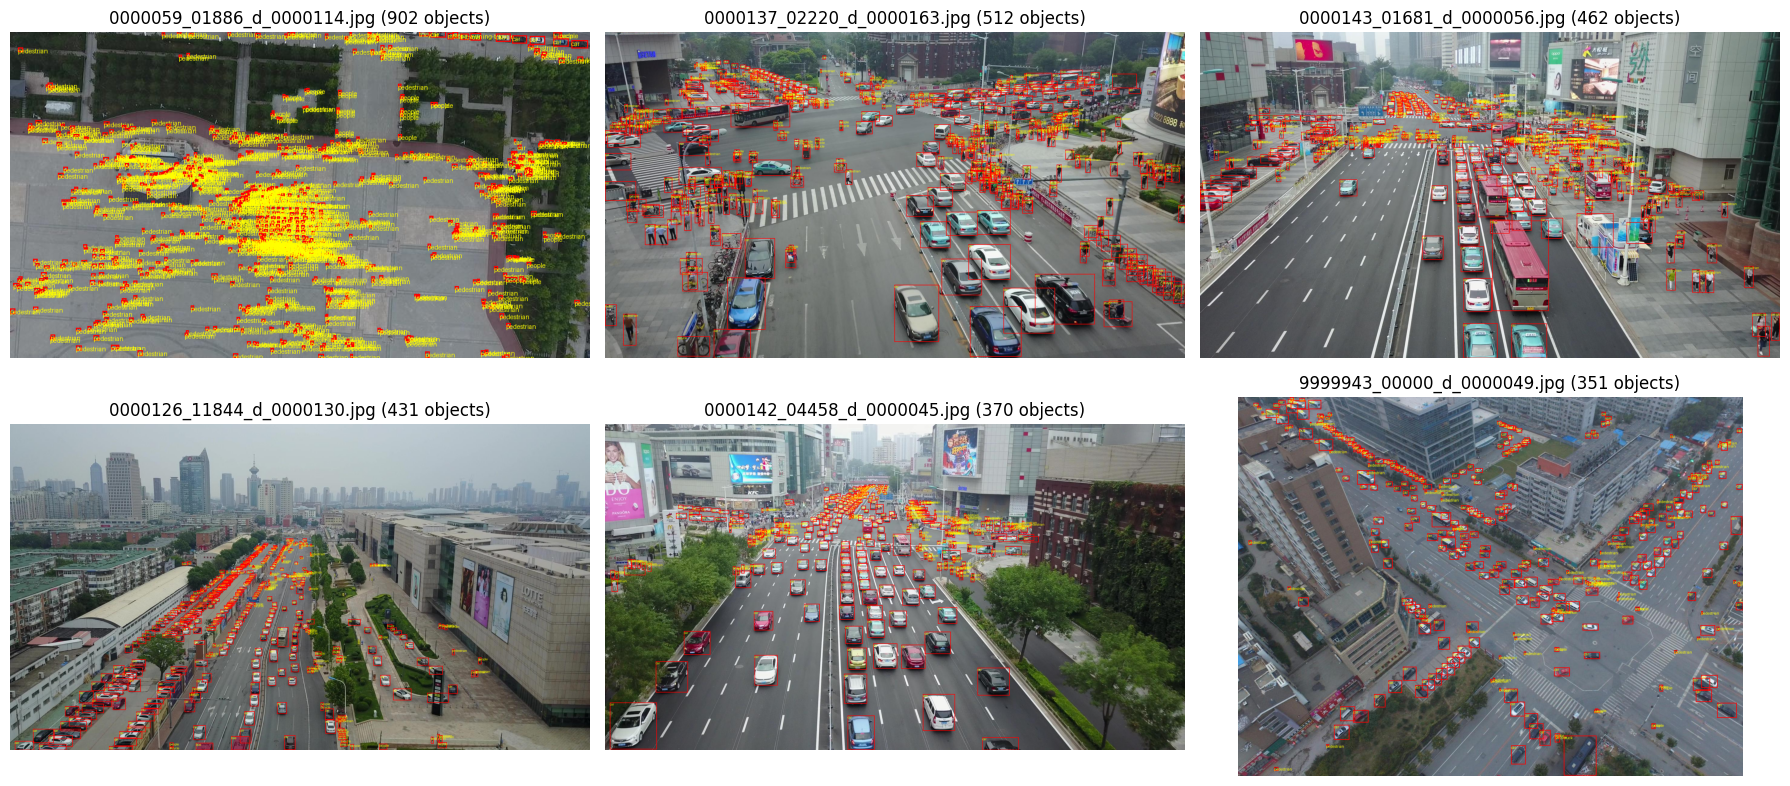

In [12]:
import matplotlib.pyplot as plt
from PIL import ImageDraw
from src.data.dataloaders import CocoDetectionRecords
visual_track = "10class" if "10class" in TRACKS else "2class"
records = CocoDetectionRecords(
    paths.coco(visual_track) / "train",
    paths.coco(visual_track) / "annotations/instances_train.json",
)
def interest(record):
    annotations = record["annotations"]
    tiny = sum(float(item["area"]) < 32**2 for item in annotations)
    classes = len({int(item["category_id"]) for item in annotations})
    attributes = [item.get("attributes", {}) for item in annotations]
    difficult = sum(
        int(item.get("occlusion", 0)) > 0 or int(item.get("truncation", 0)) > 0
        for item in attributes
    )
    return (len(annotations), tiny, classes, difficult, -record["image_id"])
selected = sorted((records[index] for index in range(len(records))), key=interest, reverse=True)[:6]
if len(selected) < 6:
    raise RuntimeError("At least six converted images are required for visualization")
figure, axes = plt.subplots(2, 3, figsize=(18, 8))
for axis, record in zip(axes.flat, selected):
    canvas = record["image"].copy()
    draw = ImageDraw.Draw(canvas)
    for annotation in record["annotations"]:
        x, y, width, height = annotation["bbox"]
        label = records.categories[int(annotation["category_id"])]
        draw.rectangle((x, y, x + width, y + height), outline="red", width=2)
        draw.text((x, y), label, fill="yellow")
    axis.imshow(canvas)
    axis.set_title(f"{record['file_name']} ({len(record['annotations'])} objects)")
    axis.axis("off")
plt.tight_layout()
plt.show()


## 13. DataLoader smoke test


In [13]:
from src.data.dataloaders import detection_collate
try:
    from torch.utils.data import DataLoader
    loader = DataLoader(records, batch_size=min(2, len(records)), shuffle=False, collate_fn=detection_collate)
    batch = next(iter(loader))
except ImportError:
    print("PyTorch is absent; using the identical collate path for this local CPU verification.")
    batch = detection_collate([records[index] for index in range(min(2, len(records)))])
assert batch and all(item["image"].mode == "RGB" and item["original_size"] for item in batch)
print("Valid batch:", [(item["image_id"], item["original_size"], len(item["annotations"])) for item in batch])


Valid batch: [(1, (540, 960), 82), (2, (540, 960), 85)]


## 14. Final summary and next notebook


In [14]:
print("VisDrone setup complete.")
print("Persistent root:", paths.root)
print("Raw data:", paths.raw)
for track in TRACKS:
    print(track, "COCO:", paths.coco(track))
print("Manifests:", paths.dataset_manifests)
print("Next notebook: notebooks/01_dataset_analysis.ipynb")


VisDrone setup complete.
Persistent root: /content/drive/MyDrive/visdrone_architecture_benchmark
Raw data: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/raw
2class COCO: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/processed/coco_2class
10class COCO: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/processed/coco_10class
Manifests: /content/drive/MyDrive/visdrone_architecture_benchmark/datasets/VisDrone2019-DET/manifests
Next notebook: notebooks/01_dataset_analysis.ipynb
